# Análisis Exploratorio de Datos (EDA): Esperanza de Vida.
Este notebook tiene como objetivo explorar los datos de la OMS para entender qué factores influyen en la esperanza de vida, centrándonos en la **escolarización y el consumo de alcohol**.

## Carga de Librerías y Datos

In [310]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv('../../data/raw/LifeExpectancyData_raw.csv')

df.shape

(2938, 22)

In [311]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [312]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [313]:
df.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


## Limpieza Inicial
 Vamos a limpiar los nombres de las columnas para eliminar espacios en blanco innecesarios

In [314]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')


In [315]:
df.columns =df.columns.str.strip()
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')


In [316]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Se puede observar que hay pacientes con muchas lagunas, columnas con datos faltantes, nulos, etc. Vamos a realizar lo que se llama **Data Wrangling**.

## Limpieza Profunda
### Comprobamos si hay filas donde **Life expectancy** es nulo y si es así se eliminan del dataset.

In [317]:
df = df.dropna(subset=['Life expectancy'])
print(f"Filas tras eliminar nulos en el target: {df.shape[0]}")

Filas tras eliminar nulos en el target: 2928


## Imputación de los datos
Para las columnas numéricas, vamos a rrelenar los nulos con la MEDIANA. Esta opción es más robusta frente a los outliers.


## Comprobamos nulos

In [318]:
print(df.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                            193
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 32
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                443
Population                         644
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64


### Rellenamos huecos

In [319]:
columnas_con_nulos = ['Alcohol', 'Schooling', 'Hepatitis B', 'BMI', 'Polio', 
                      'Total expenditure', 'Diphtheria', 'GDP', 'Population', 
                      'Income composition of resources','thinness  1-19 years', 'thinness 5-9 years']

for col in columnas_con_nulos:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64


## Detectar Outliers

In [320]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2928.00000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2928.000000,2.928000e+03,2928.000000,2928.000000,2928.000000,2928.000000
mean,2007.50000,69.224932,164.796448,30.407445,4.559167,740.321185,83.045765,2427.855874,38.291291,42.179303,82.616120,5.916257,82.390710,1.747712,6627.389707,1.026315e+07,4.833675,4.865232,0.630128,12.016052
std,4.61056,9.523867,124.292079,118.114450,3.920534,1990.930605,22.942047,11485.970937,19.857308,160.700547,23.355634,2.385963,23.645132,5.085542,13316.392534,5.411179e+07,4.399553,4.487535,0.205440,3.254407
min,2000.00000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.75000,63.100000,74.000000,0.000000,1.107500,4.853964,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,578.797095,4.181205e+05,1.600000,1.600000,0.504000,10.300000
50%,2007.50000,72.100000,144.000000,3.000000,3.770000,65.611455,92.000000,17.000000,43.350000,4.000000,93.000000,5.750000,93.000000,0.100000,1764.973870,1.391756e+06,3.300000,3.400000,0.677000,12.300000
75%,2011.25000,75.700000,228.000000,22.000000,7.400000,442.614322,96.000000,362.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4793.630903,4.592777e+06,7.100000,7.200000,0.773000,14.100000
max,2015.00000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Vemos algunos valores atipicos que se alejan del resto considerablemente: Schooling tiene valores 0 y es raro que un país tenga 0 como valor de escolaridad. También podemos observar que en los valores de Adult Mortality hay un 1 y en infant deaths 1800. Evidentemente son valores extremos.

Vamos cuántos países hay con escolaridad 0. Si hay muchos se tratan como nulos

In [321]:
print(f"Países con escolaridad 0: {len(df[df['Schooling'] == 0])}")

Países con escolaridad 0: 26


### Visualización de Outliers

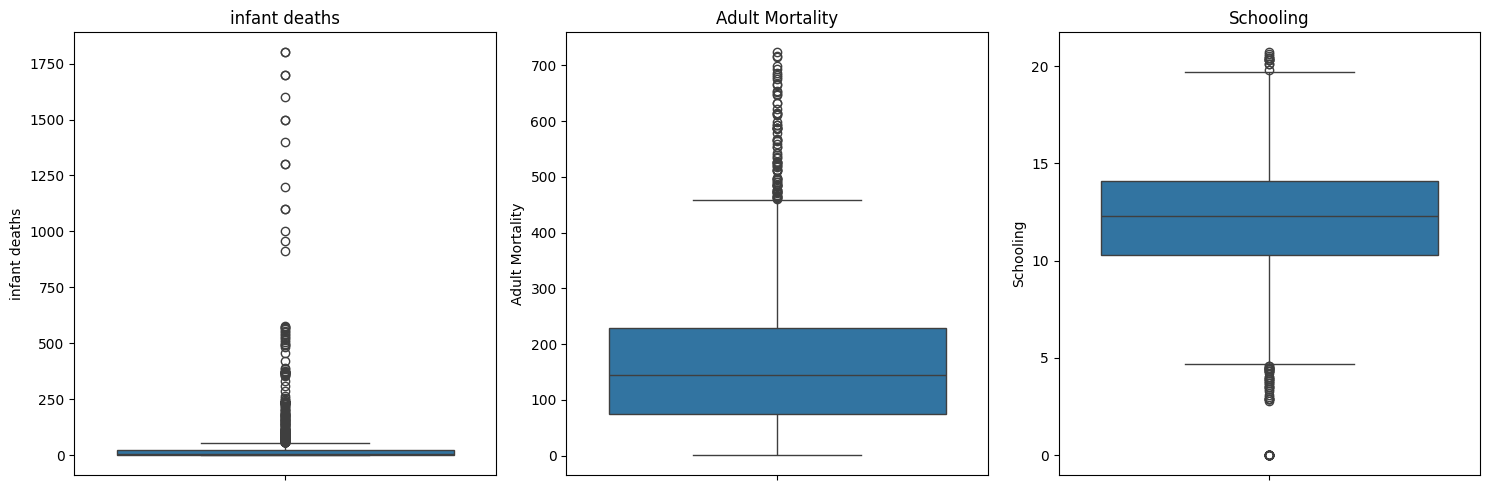

In [322]:
cols_to_check = ['infant deaths', 'Adult Mortality', 'Schooling']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Schooling = 0: Probablemente sean datos no registrados adecuadamente.<br>
Adult Mortality = 1: Que solo muera 1 persona de cada 1000 es casi imposible (el mínimo biológico es más alto).<br>
Infant deaths = 1800: Que el resto de países tengan valores bajos hace que éste valor rompa nuestra línea de regresión.

### Corregimos valores

Schooling con valor 0 los eliminamos porque son pocos.<br>
Adult Mortality con valores menores a 2 o 3  son sospechosos.<br>
Infant deaths con valores extremos se eliminan también.

In [323]:
df = df[df['Schooling'] > 0]
df = df[df['Adult Mortality'] > 1]
limite_superior_infant = df['infant deaths'].quantile(0.99)
df =df[df['infant deaths'] <= limite_superior_infant]

print(f"Registros restantes tras limpiar outliers: {df.shape[0]}")

Registros restantes tras limpiar outliers: 2861


In [324]:
df.info()

<class 'pandas.DataFrame'>
Index: 2861 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2861 non-null   str    
 1   Year                             2861 non-null   int64  
 2   Status                           2861 non-null   str    
 3   Life expectancy                  2861 non-null   float64
 4   Adult Mortality                  2861 non-null   float64
 5   infant deaths                    2861 non-null   int64  
 6   Alcohol                          2861 non-null   float64
 7   percentage expenditure           2861 non-null   float64
 8   Hepatitis B                      2861 non-null   float64
 9   Measles                          2861 non-null   int64  
 10  BMI                              2861 non-null   float64
 11  under-five deaths                2861 non-null   int64  
 12  Polio                            286

## Análisis de Realciones (EDA)


### Análisis Bivariante

### Pregunta 5: ¿Cuál es el impacto de la escolarización en la esperanza de vida de los seres humanos?

Escolaridad vs. Esperanza de Vida.

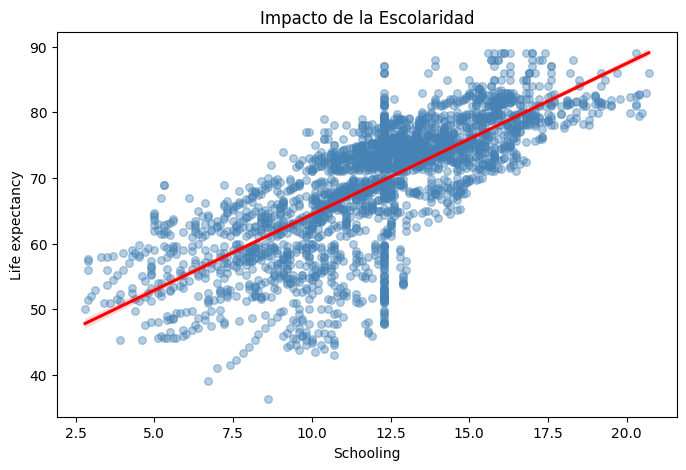

Correlación: 0.75


In [325]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Schooling', y='Life expectancy', line_kws={'color':'red'}, scatter_kws={
    'alpha': 0.4,
    's': 30,
    'color': 'steelblue'
})
plt.title('Impacto de la Escolaridad')
plt.show()

print(f"Correlación: {df['Schooling'].corr(df['Life expectancy']):.2f}")

Existe una fuerte correlación positiva entre los años de escolarización y la esperanza de vida, lo que indica que mayores niveles educativos están asociados con una mayor longevidad.

### Pregunta 6: ¿Existe una relación positiva o negativa entre la esperanza de vida y el consumo de alcohol?

Alcohol vs. Esperanza de Vida.

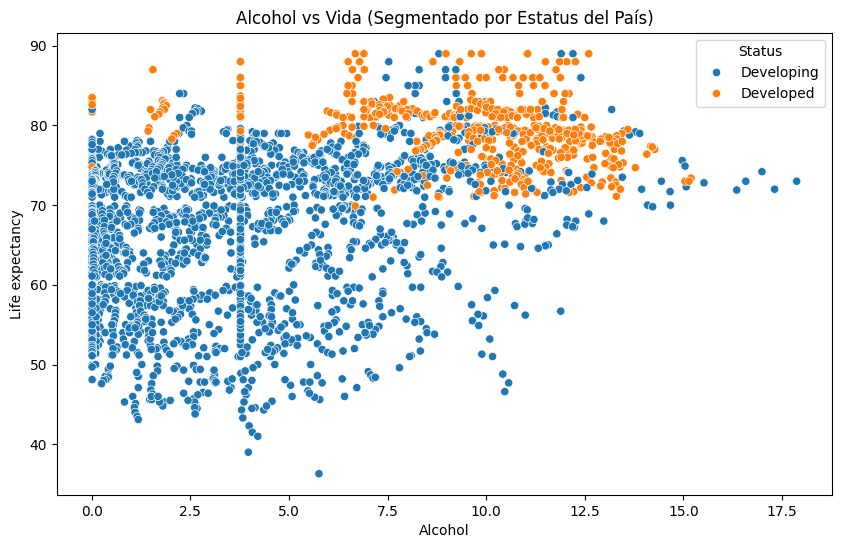

In [326]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Alcohol', y='Life expectancy', hue='Status')
plt.title('Alcohol vs Vida (Segmentado por Estatus del País)')
plt.show()

La esperanza de vida no presenta una correlación lineal significativa con el consumo de alcohol. La aparente relación positiva observada en países desarrollados está mediada por factores socioeconómicos y sanitarios, no por el alcohol en sí mismo.

### Análisis multivariante (Mapa de Calor)

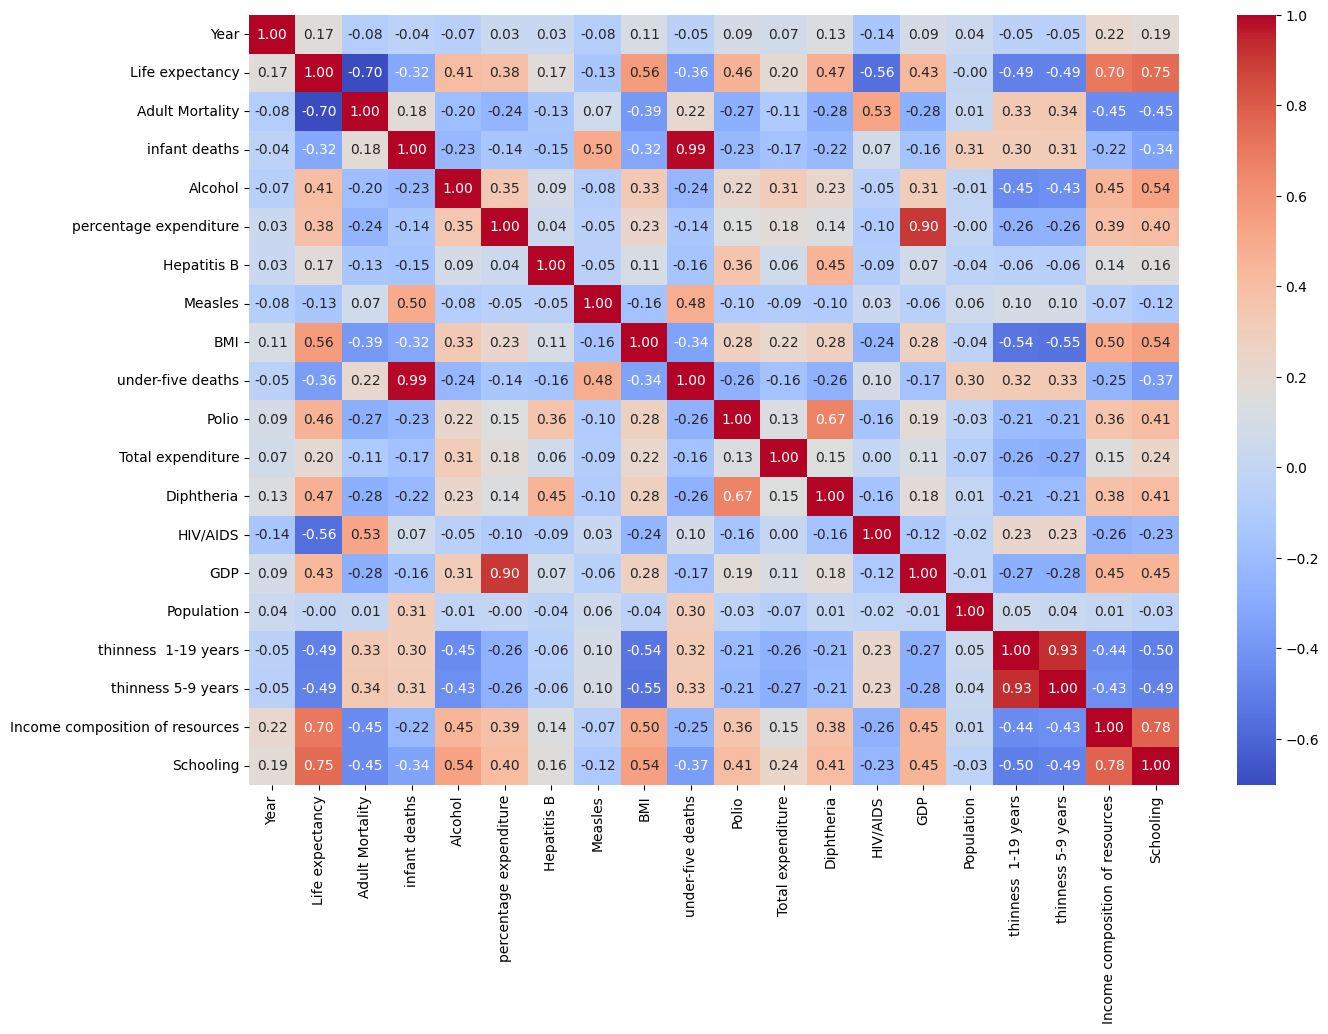

In [327]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

La esperanza de vida aumenta claramente con la escolarización (r = 0.75) y el nivel económico (r = 0.70). También mejora con una mejor nutrición (IMC, r = 0.56) y mayor vacunación (r ≈ 0.46).

En cambio, disminuye notablemente con la mortalidad adulta (r = -0.70), el VIH/SIDA (r = -0.56) y la desnutrición infantil (r ≈ -0.49).

## Pre-processing

### Convertir texto en números (Encoding)

In [328]:
df['Status_encoded'] = df['Status'].map({'Developed': 1, 'Developing': 0})

### División del Dataset (Train/Test Split)

In [329]:
X = df.drop(['Life expectancy', 'Country', 'Status'], axis=1)
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar: {X_train.shape[0]}")
print(f"Datos para probar: {X_test.shape[0]}")

Datos para entrenar: 2288
Datos para probar: 573


## Entrenamiento

In [330]:
model = LinearRegression()

model.fit(X_train, y_train)

print("¡Entrenamiento completado!")

¡Entrenamiento completado!


## Evaluación

In [331]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Puntuación R² (Precisión): {r2:.4f}")
print(f"Error Medio (MAE): {mae:.2f} años")

Puntuación R² (Precisión): 0.8196
Error Medio (MAE): 3.08 años


In [332]:
coeficientes = pd.DataFrame({'Variable': X.columns, 'Impacto': model.coef_})
print(coeficientes.sort_values(by='Impacto', ascending=False))

                           Variable       Impacto
17  Income composition of resources  6.726059e+00
19                   Status_encoded  1.701258e+00
18                        Schooling  7.596541e-01
2                     infant deaths  1.644005e-01
10                Total expenditure  1.213104e-01
11                       Diphtheria  3.270082e-02
7                               BMI  3.121625e-02
9                             Polio  2.378650e-02
16               thinness 5-9 years  5.019458e-03
3                           Alcohol  1.596498e-03
4            percentage expenditure  5.404734e-05
13                              GDP  3.832219e-05
14                       Population  4.942679e-09
6                           Measles -1.928832e-05
5                       Hepatitis B -1.478688e-02
1                   Adult Mortality -1.831138e-02
0                              Year -2.633234e-02
15             thinness  1-19 years -6.256336e-02
8                 under-five deaths -1.297226e-01


### Respuestas:

- Schooling = 1.596498×10−3=0.001596498≈0.0016
- Alcohol = 1.596498×10−3=0.001596498≈0.0016

¿Qué impacto tiene la escolaridad (Schooling) en la esperanza de vida?:

    "La escolaridad tiene un impacto positivo muy fuerte. Por cada año adicional de escolarización, la esperanza de vida aumenta en promedio 0.75 años. Es uno de los motores más importantes para la longevidad según nuestro modelo."

 ¿El alcohol tiene una relación positiva o negativa? :

    "El alcohol muestra una relación positiva leve en el modelo global. Sin embargo, como científicos de datos, interpretamos que esto no se debe a que el alcohol sea saludable, sino a que está correlacionado con países de Estatus Desarrollado, que tienen mejores sistemas de salud y mayor poder adquisitivo."